# 01 - Synthetic Setup and Pricing

This notebook introduces the synthetic market used throughout the repository and compares two dependence models for a European basket call.

**Contract.** The basket value is

$$
B_t = \sum_{i=1}^N w_i S_i(t),
$$

and the terminal payoff is

$$
g(S_T) = (B_T - K)^+.
$$

**Models.** The marginal stock dynamics follow a multi-asset Black-Scholes specification under the risk-neutral measure. The comparison is between:

1. a constant-correlation model with one fixed correlation matrix;
2. a two-state regime-switching model with separate calm and stress correlation matrices.

**What this notebook does.**

1. specifies the baseline synthetic market inputs;
2. simulates stock paths under both dependence models;
3. checks the empirical correlation structure implied by those simulations;
4. estimates the basket-call price by Monte Carlo and records convergence diagnostics.

The resulting baseline artifacts are saved in `outputs/synthetic`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Resolve repository paths so the notebook works from a clone or a ZIP extract.

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").is_dir()
            and (candidate / "scripts").is_dir()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the project root. Run the notebook from inside the extracted repository.")


PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / "outputs" / "synthetic"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from synthetic_analysis_utils import (
    TRADING_DAYS_PER_YEAR,
    average_off_diagonal,
    basket_call_payoff,
    basket_values,
    build_transition_matrix,
    empirical_return_correlation,
    equicorrelation_matrix,
    evaluate_hedger,
    initial_hedge_from_model,
    monte_carlo_price_summary,
    pnl_summary,
    simulate_constant_paths,
    simulate_regime_switching_paths,
    summary_frame_from_results,
    unhedged_short_pnl,
)

In [2]:
asset_names = np.array(["Asset 1", "Asset 2", "Asset 3"])
spot = np.array([100.0, 95.0, 110.0])
weights = np.array([0.40, 0.35, 0.25])
vol = np.array([0.20, 0.25, 0.22])
div_yield = np.zeros_like(spot)

rate = 0.03
maturity = 1.0
daily_steps = TRADING_DAYS_PER_YEAR
n_paths = 3000
strike = float(weights @ spot)
start_regime = 0

rho_constant_level = 0.35
rho_calm_level = 0.20
rho_stress_level = 0.75
p01_daily = 0.03
p10_daily = 0.12

corr_constant = equicorrelation_matrix(len(spot), rho_constant_level)
corr_calm = equicorrelation_matrix(len(spot), rho_calm_level)
corr_stress = equicorrelation_matrix(len(spot), rho_stress_level)
transition_daily = build_transition_matrix(p01_daily, p10_daily)

asset_params = pd.DataFrame(
    {
        "asset": asset_names,
        "spot": spot,
        "weight": weights,
        "annualized_volatility": vol,
        "dividend_yield": div_yield,
    }
)
market_settings = pd.DataFrame(
    [
        {"parameter": "rate", "value": rate},
        {"parameter": "maturity", "value": maturity},
        {"parameter": "daily_steps", "value": daily_steps},
        {"parameter": "paths", "value": n_paths},
        {"parameter": "strike", "value": strike},
        {"parameter": "start_regime", "value": start_regime},
        {"parameter": "rho_constant", "value": rho_constant_level},
        {"parameter": "rho_calm", "value": rho_calm_level},
        {"parameter": "rho_stress", "value": rho_stress_level},
        {"parameter": "p01_daily", "value": p01_daily},
        {"parameter": "p10_daily", "value": p10_daily},
    ]
)

display(Markdown("## Baseline synthetic inputs"))
display(asset_params)
display(market_settings)

## Baseline synthetic inputs

,asset,spot,weight,annualized_volatility,dividend_yield
0,Asset 1,100.0000,0.4000,0.2000,0.0000
1,Asset 2,95.0000,0.3500,0.2500,0.0000
2,Asset 3,110.0000,0.2500,0.2200,0.0000


,parameter,value
0,rate,0.0300
1,maturity,1.0000
2,daily_steps,252.0000
3,paths,"3,000.0000"
4,strike,100.7500
5,start_regime,0.0000
6,rho_constant,0.3500
7,rho_calm,0.2000
8,rho_stress,0.7500
9,p01_daily,0.0300


In [3]:
constant_paths = simulate_constant_paths(
    spot=spot,
    rate=rate,
    div_yield=div_yield,
    vol=vol,
    maturity=maturity,
    n_steps=daily_steps,
    n_paths=n_paths,
    corr=corr_constant,
    seed=11,
)
regime_paths, regime_states = simulate_regime_switching_paths(
    spot=spot,
    rate=rate,
    div_yield=div_yield,
    vol=vol,
    maturity=maturity,
    n_steps=daily_steps,
    n_paths=n_paths,
    corr_calm=corr_calm,
    corr_stress=corr_stress,
    transition_matrix=transition_daily,
    start_regime=start_regime,
    seed=17,
)

constant_corr_empirical = pd.DataFrame(
    empirical_return_correlation(constant_paths),
    index=asset_names,
    columns=asset_names,
)
regime_corr_empirical = pd.DataFrame(
    empirical_return_correlation(regime_paths),
    index=asset_names,
    columns=asset_names,
)

np.savez(
    ANALYSIS_DIR / "baseline_market_bundle.npz",
    asset_names=asset_names,
    spot=spot,
    weights=weights,
    vol=vol,
    div_yield=div_yield,
    constant_paths=constant_paths,
    regime_paths=regime_paths,
    regime_states=regime_states,
    corr_constant=corr_constant,
    corr_calm=corr_calm,
    corr_stress=corr_stress,
    transition_daily=transition_daily,
    strike=strike,
    rate=rate,
    maturity=maturity,
    daily_steps=daily_steps,
    start_regime=start_regime,
)
asset_params.to_csv(ANALYSIS_DIR / "asset_parameters.csv", index=False)
market_settings.to_csv(ANALYSIS_DIR / "market_settings.csv", index=False)
constant_corr_empirical.to_csv(ANALYSIS_DIR / "constant_empirical_correlation.csv")
regime_corr_empirical.to_csv(ANALYSIS_DIR / "regime_empirical_correlation.csv")

display(Markdown("## Empirical correlations from the simulated path sets"))
display(constant_corr_empirical.round(4))
display(regime_corr_empirical.round(4))

## Empirical correlations from the simulated path sets

,Asset 1,Asset 2,Asset 3
Asset 1,1.0000,0.3488,0.3485
Asset 2,0.3488,1.0000,0.3492
Asset 3,0.3485,0.3492,1.0000


,Asset 1,Asset 2,Asset 3
Asset 1,1.0000,0.3078,0.3066
Asset 2,0.3078,1.0000,0.3057
Asset 3,0.3066,0.3057,1.0000


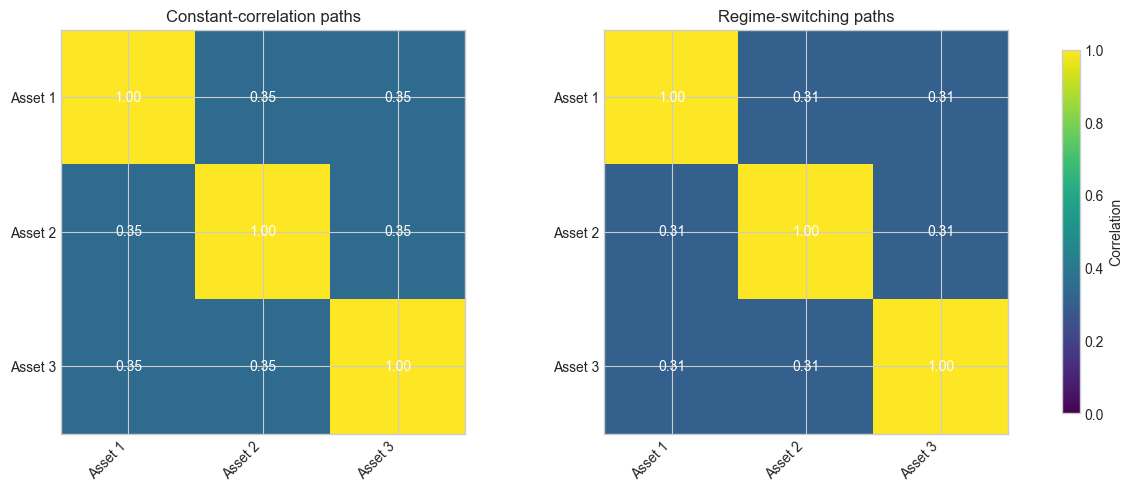

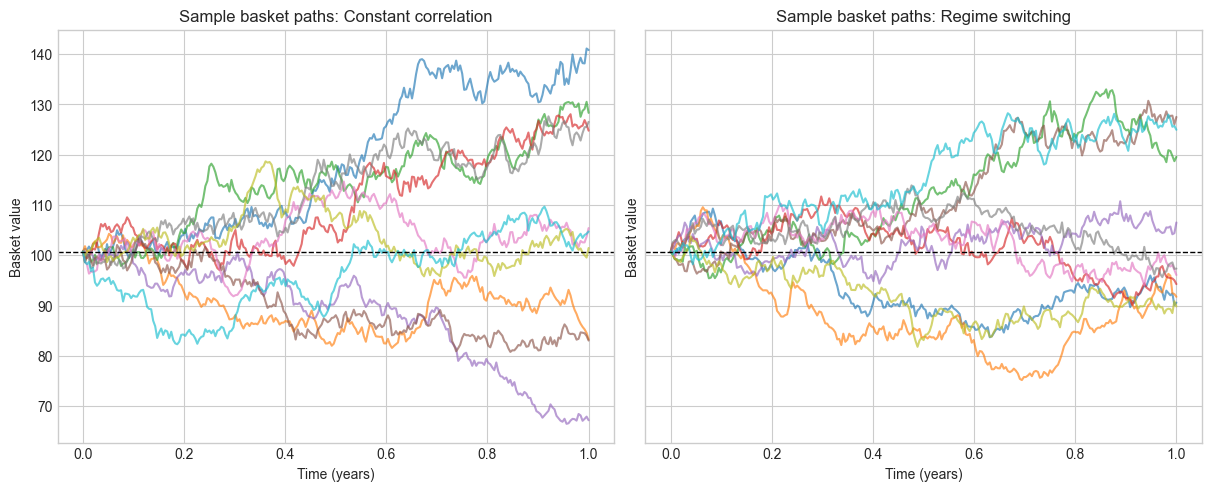

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
for ax, matrix, title in [
    (axes[0], constant_corr_empirical, "Constant-correlation paths"),
    (axes[1], regime_corr_empirical, "Regime-switching paths"),
]:
    image = ax.imshow(matrix.values, vmin=0.0, vmax=1.0, cmap="viridis")
    ax.set_xticks(range(len(asset_names)))
    ax.set_yticks(range(len(asset_names)))
    ax.set_xticklabels(asset_names, rotation=45, ha="right")
    ax.set_yticklabels(asset_names)
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix.iloc[i, j]:.2f}", ha="center", va="center", color="white")
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.9, label="Correlation")
plt.show()

constant_basket = constant_paths @ weights
regime_basket = regime_paths @ weights
sample_ids = np.random.default_rng(123).choice(n_paths, size=10, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True, constrained_layout=True)
time_grid = np.linspace(0.0, maturity, daily_steps + 1)
for sample_id in sample_ids:
    axes[0].plot(time_grid, constant_basket[sample_id], alpha=0.65)
    axes[1].plot(time_grid, regime_basket[sample_id], alpha=0.65)
for ax, title in zip(axes, ["Constant correlation", "Regime switching"]):
    ax.axhline(strike, color="black", linestyle="--", linewidth=1.0)
    ax.set_title(f"Sample basket paths: {title}")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Basket value")
plt.show()

In [5]:
discount = np.exp(-rate * maturity)
constant_discounted_payoffs = discount * basket_call_payoff(constant_paths[:, -1, :], weights, strike)
regime_discounted_payoffs = discount * basket_call_payoff(regime_paths[:, -1, :], weights, strike)

pricing_summary = pd.DataFrame(
    [
        monte_carlo_price_summary(
            constant_discounted_payoffs,
            "Constant correlation",
            {
                "avg_terminal_basket": float(constant_basket[:, -1].mean()),
                "avg_stress_fraction": np.nan,
            },
        ),
        monte_carlo_price_summary(
            regime_discounted_payoffs,
            "Regime switching",
            {
                "avg_terminal_basket": float(regime_basket[:, -1].mean()),
                "avg_stress_fraction": float(regime_states.mean()),
            },
        ),
    ]
)
pricing_summary["price_difference_vs_constant"] = pricing_summary["price"] - pricing_summary.loc[0, "price"]

convergence_grid = [100, 250, 500, 1000, 1500, 2000, 2500, 3000]
convergence_rows = []
for model_name, discounted_payoffs in [
    ("Constant correlation", constant_discounted_payoffs),
    ("Regime switching", regime_discounted_payoffs),
]:
    for m in convergence_grid:
        convergence_rows.append(
            {
                "model": model_name,
                **monte_carlo_price_summary(discounted_payoffs[:m], model_name),
            }
        )

convergence = pd.DataFrame(convergence_rows)

pricing_summary.to_csv(ANALYSIS_DIR / "baseline_pricing_summary.csv", index=False)
convergence.to_csv(ANALYSIS_DIR / "baseline_pricing_convergence.csv", index=False)

display(Markdown("## Pricing summary"))
display(pricing_summary.round(4))

## Pricing summary

,model,price,std_error,ci_low,ci_high,discounted_payoff_std,n_paths,avg_terminal_basket,avg_stress_fraction,price_difference_vs_constant
0,Constant correlation,8.4681,0.2233,8.0303,8.9058,12.2330,3000,104.3065,NaN,0.0000
1,Regime switching,8.3723,0.2163,7.9483,8.7963,11.8487,3000,104.1871,0.1956,-0.0958


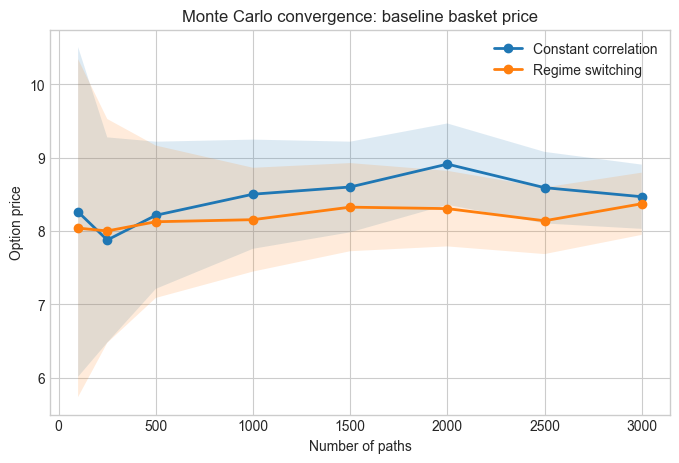

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for model_name, frame in convergence.groupby("model"):
    frame = frame.sort_values("n_paths")
    ax.plot(frame["n_paths"], frame["price"], marker="o", linewidth=2, label=model_name)
    ax.fill_between(frame["n_paths"], frame["ci_low"], frame["ci_high"], alpha=0.15)

ax.set_title("Monte Carlo convergence: baseline basket price")
ax.set_xlabel("Number of paths")
ax.set_ylabel("Option price")
ax.legend()
plt.show()

## Takeaway

The baseline synthetic pricing result is intentionally mild: the constant and regime-switching models are close in price at time 0.

That is the right setup for the rest of the project, because it isolates the more interesting question:
**can two models with similar prices still produce different hedging outcomes?**